HOMEWORK 1

LUCA NICOLOSI 1000047978

In [1]:
import pandas as pd

import matplotlib.pyplot as plt

import yfinance as yf

In [2]:
# STEP 0

df = pd.read_csv('symbol_info_3-25.csv') # I'm importing the dataset

df_clean = df[(df['is_actively_trading'] == 1) & (df['is_etf'] == 0) & (df['is_fund'] == 0)] # I'm selecting only the active companies excluding those who invest in ETF and funds

df_sector = df_clean[df_clean['sector'] == 'Basic Materials'].copy() # I'm selecting the companies which belong to th Basic Materials industry


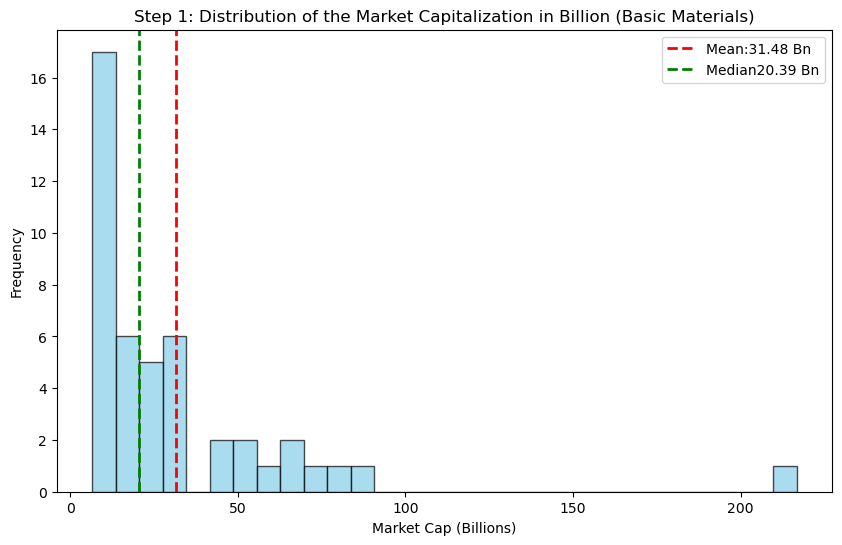

In [3]:
# STEP 1

df_sector['market_cap_b'] = df_sector['market_cap'] / 1e9 # I'm creating a new variable which includes the market_cap variable in billion

plt.figure(figsize=(10,6)) # here I'm setting the dimension of the plot. 10 indicates the width and 6 the height 

plt.hist(df_sector['market_cap_b'], bins= 30, color= 'skyblue', edgecolor= 'black', alpha = 0.7) # I'm creating the histogram based on df_sector. Bins = 30 means that the histogram is going to have 30 columns.

mean_market_cap = df_sector['market_cap_b'].mean() # I'm computing the mean of the market_cap variable
median_market_cap = df_sector['market_cap_b'].median() # I'm computing the median of the market_cap variable

plt.axvline(mean_market_cap, color = 'red', linestyle= 'dashed', linewidth = 2, label = f'Mean:{mean_market_cap:.2f} Bn') # I'm adding into the histogram a line which indicates the mean  of the market_cap variable.
plt.axvline(median_market_cap,color = 'green', linestyle = 'dashed', linewidth = 2, label = f'Median{median_market_cap:.2f} Bn' ) # I'm addinto into the hostogram a line which indicates the median of the market_cap variable.

plt.title('Step 1: Distribution of the Market Capitalization in Billion (Basic Materials)') # I'm adding the title of the plot
plt.xlabel('Market Cap (Billions)') # I'm adding a label for the x axis 
plt.ylabel('Frequency') # I'm adding a label for the y axis 
plt.legend() # I'm adding a legend
plt.show()


            







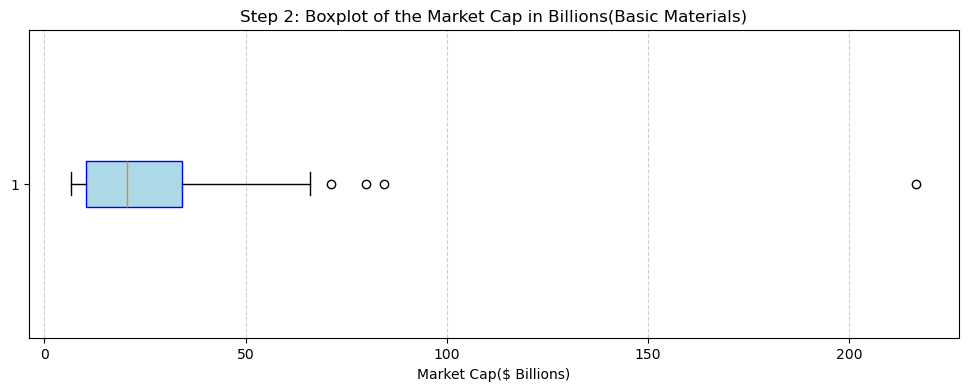

In [4]:
# STEP 2

plt.figure(figsize=(12,4))

plt.boxplot(df_sector['market_cap_b'], vert= False, patch_artist= True, boxprops=dict(facecolor= 'lightblue', color = 'blue')) # now I'm creating the boxplot. With vert = False the boxplot is going to be horizontal. Patch_artist = True allows me to specify the color inside the box. Finally with boxprops I'm defining the properties of the box.

plt.title('Step 2: Boxplot of the Market Cap in Billions(Basic Materials)')
plt.xlabel('Market Cap($ Billions)')
plt.grid(axis= 'x', linestyle= '--', alpha = 0.6)
plt.show()

Q1 = df_sector['market_cap_b'].quantile(0.25)
Q3 = df_sector['market_cap_b'].quantile(0.75)
IQR = Q3 - Q1

limit = Q3 + 1.5 * IQR # since the distribution of the market_cap variable is right skewned, the outliers are concentred on the right side of the plot. This means that the outliers are represented by companies with an extremely high market capitalization.
df_filtered = df_sector[df_sector['market_cap_b'] <= limit].copy() # now I'm filtering the data frame by considering all the companies with a market capitalization which is below than or equal to the limit.




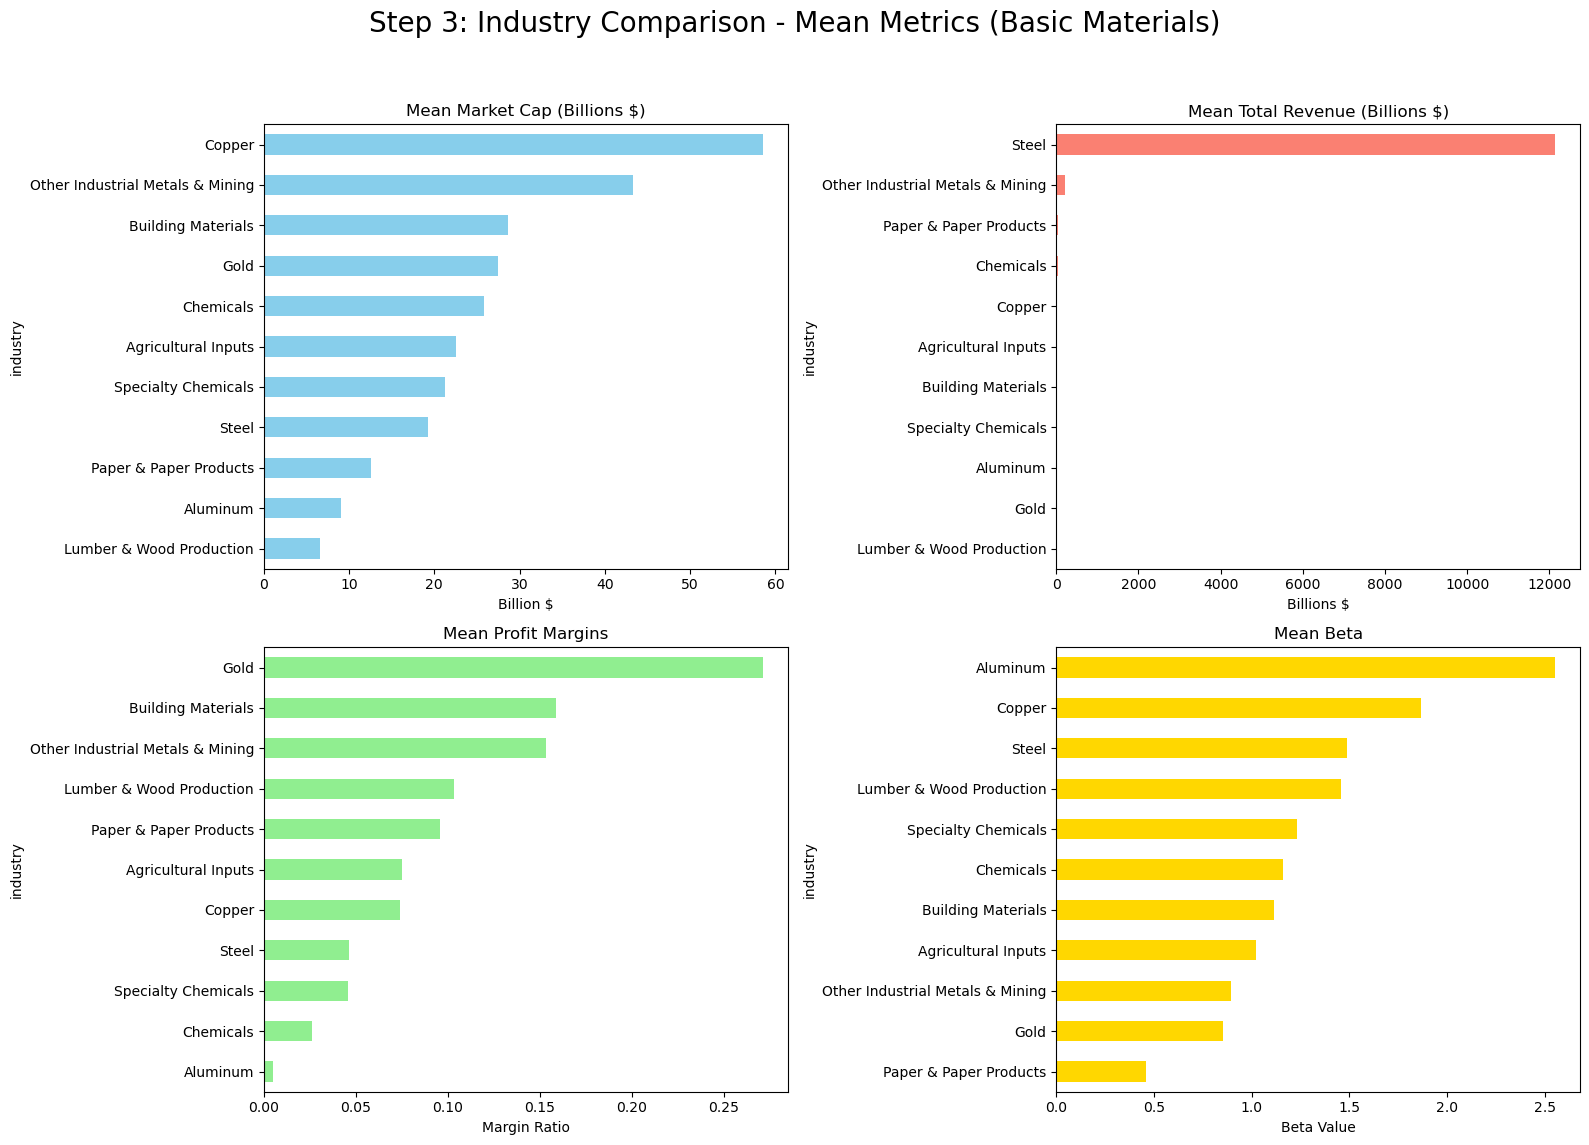

In [5]:
# STEP 3

df_filtered['total_revenue_b'] = df_filtered['total_revenue'] / 1e9

industry_comparison = df_filtered.groupby('industry')[['market_cap_b', 'total_revenue_b', 'profit_margins', 'beta']].mean() # By using groupby, I'm computing the mean of those variables by considering only the industries.

fig,axes = plt.subplots(2,2, figsize = (16,12))
fig.suptitle('Step 3: Industry Comparison - Mean Metrics (Basic Materials)', fontsize = 20) # I'm setting the title of the overall plot

# Graph 1 
industry_comparison['market_cap_b'].sort_values().plot(kind = 'barh', ax = axes[0,0], color = 'skyblue') # I'm creating an horizontal bar chart considering the ordered values of the market capitalization espressed in billions
axes[0,0].set_title('Mean Market Cap (Billions $)') 
axes[0,0].set_xlabel('Billion $')

#  Graph 2 
industry_comparison['total_revenue_b'].sort_values().plot(kind= 'barh', ax = axes[0,1],color = 'salmon') # I'm creating an horizontal bar chart considering the ordered values of the total revenue espressed in billions
axes[0,1].set_title('Mean Total Revenue (Billions $)')
axes[0,1].set_xlabel('Billions $')

# Graph 3 
industry_comparison['profit_margins'].sort_values().plot(kind= 'barh', ax = axes[1,0], color = 'lightgreen') # I'm creating an horizontal bar chart considering the ordered values of the profit margins
axes[1,0].set_title('Mean Profit Margins')
axes[1,0].set_xlabel('Margin Ratio')

# Graph 4
industry_comparison['beta'].sort_values().plot(kind= 'barh', ax = axes[1,1], color='gold') # I'm creating an horizontal bar chart considering the ordered values of the beta variable.
axes[1,1].set_title('Mean Beta')
axes[1,1].set_xlabel('Beta Value')


plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Allow me to adjust the subplots layout to prevent overlapping and leave space for the main title
plt.show()










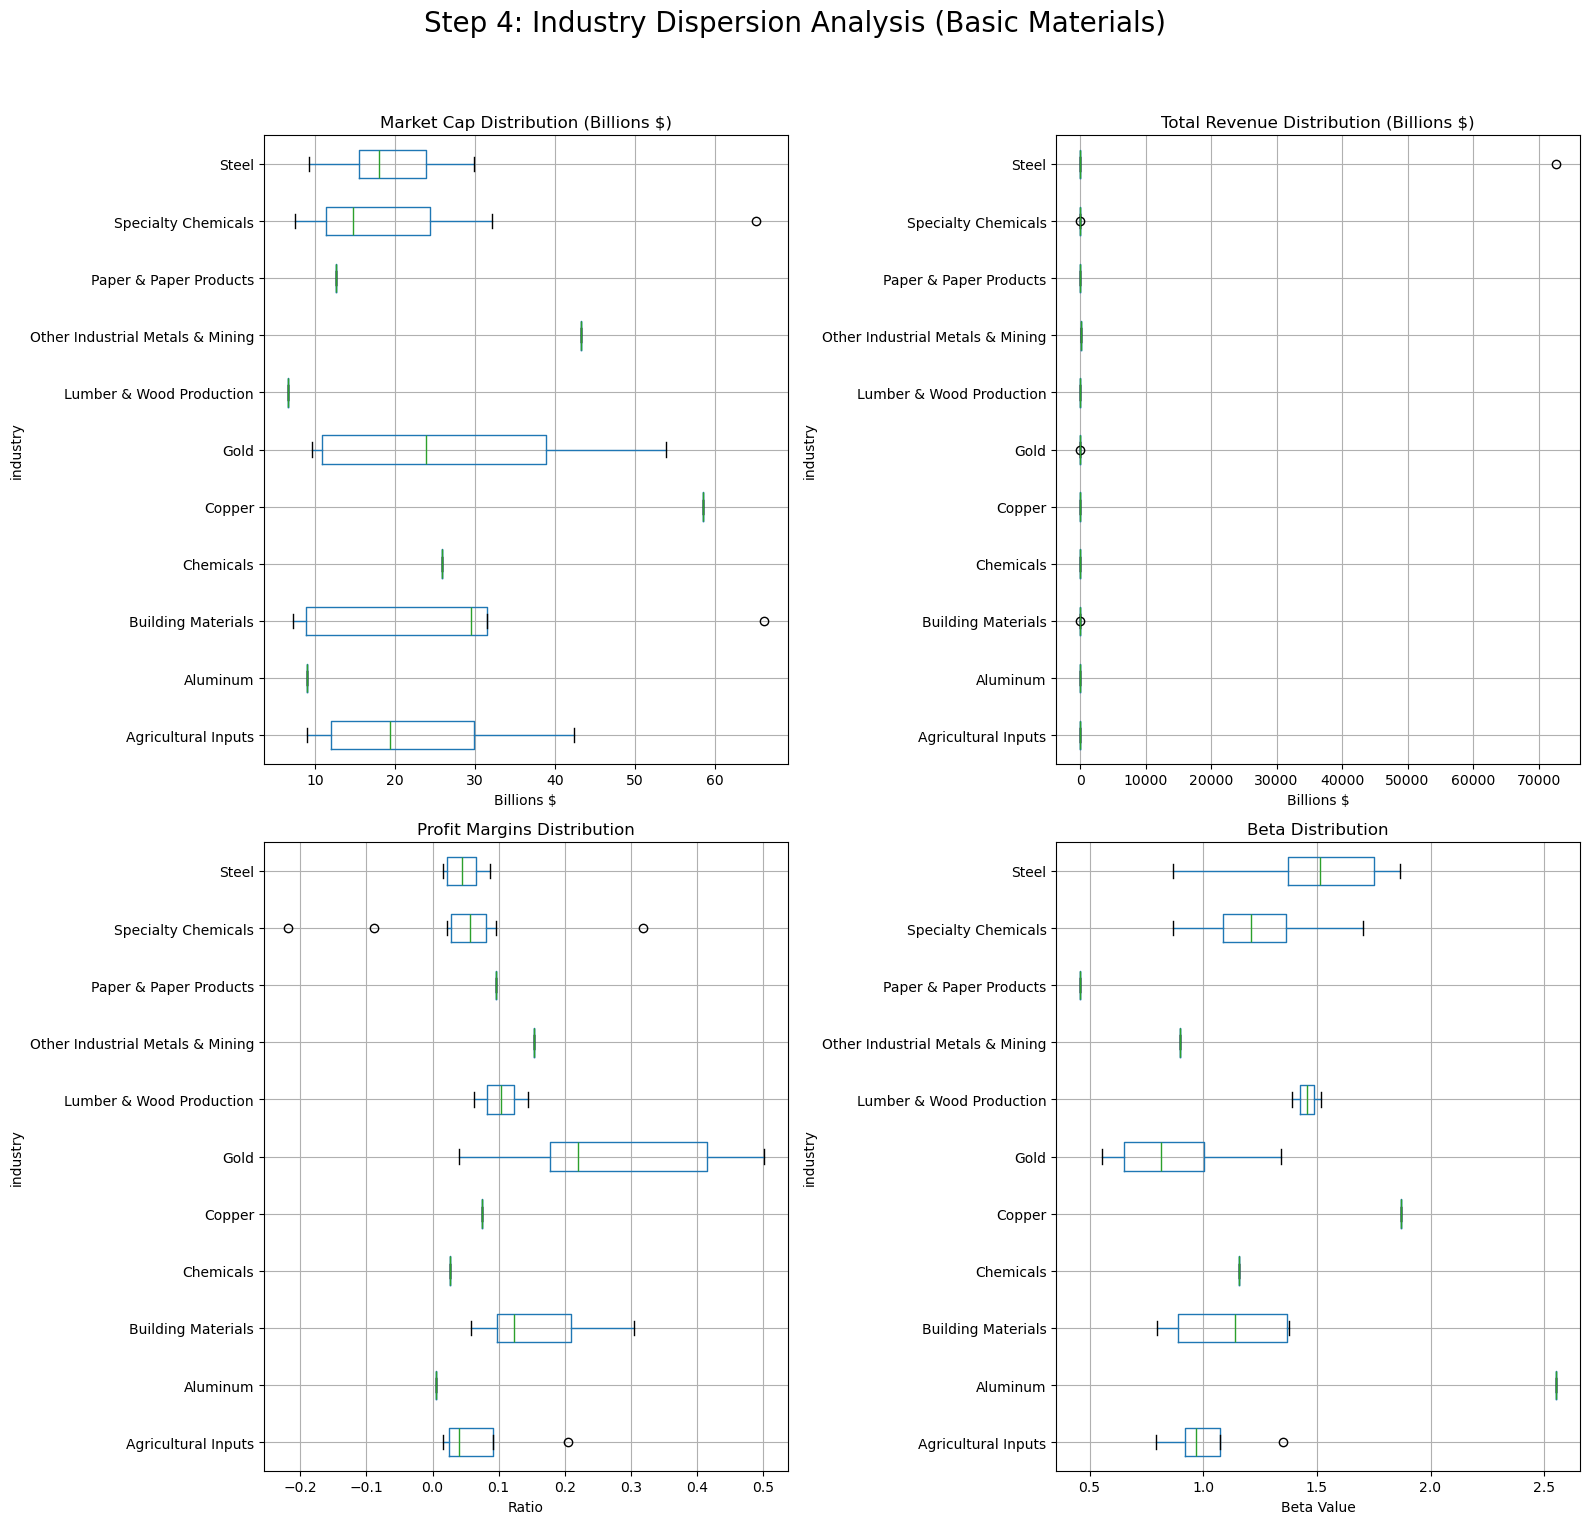

In [ ]:
# STEP 4

fig, axes = plt.subplots(2,2, figsize= (16,16))


# Graph 1
df_filtered.boxplot(column= 'market_cap_b', by = 'industry', ax = axes[0,0], vert = False) # I'm creating a boxplot which shows the dispersion of the market_cap variable espressed in billions in each industry.
axes[0,0].set_title('Market Cap Distribution (Billions $)')
axes[0,0].set_xlabel('Billions $')

# Graph 2
df_filtered.boxplot(column='total_revenue_b', by = 'industry', ax= axes[0,1], vert = False) # I'm creating a boxplot which shows the dispersion of the total revenue variable espressed in billions in each industry.
axes[0,1].set_title('Total Revenue Distribution (Billions $)')
axes[0,1].set_xlabel('Billions $')

# Graph 3
df_filtered.boxplot(column= 'profit_margins', by = 'industry', ax = axes[1,0], vert = False ) # I'm creating a boxplot which shows the dispersion of the profit margins variable in each industry.
axes[1,0].set_title('Profit Margins Distribution')
axes[1,0].set_xlabel('Ratio')

df_filtered.boxplot(column= 'beta', by = 'industry', ax = axes[1,1], vert = False) # I'm creating a boxplot which shows the dispersion of the beta variable in each industry.
axes[1,1].set_title('Beta Distribution')
axes[1,1].set_xlabel('Beta Value')

fig.suptitle('Step 4: Industry Dispersion Analysis (Basic Materials)', fontsize = 20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

In [17]:
# STEP 5

selected_industries = ['Copper', 'Gold', 'Steel', 'Aluminum'] # I'm creating a list made which includes the name of the industries that I want to carry forward

df_industries = df_filtered[df_filtered['industry'].isin(selected_industries)].copy() # By using the isin() function I'm filtering the data frame by considering the companies which belong to that kind of industry

print(f'the number of companies is: {len(df_industries)}') 

df_industries.head()

the number of companies is: 16


,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,...,short_ratio,exchange,exchange_short_name,country,is_etf,is_fund,is_actively_trading,timestamp,market_cap_b,total_revenue_b
203,FCX,"Freeport-McMoRan, Inc.",Basic Materials,Copper,58488885248,74854187008,40.250000,40.700001,55.240002,33.980000,...,1.81,NYQ,NYQ,United States,0,0,1,2025-03-22 04:52:35,58.488885,25.455000
220,NEM,Newmont Corporation,Basic Materials,Gold,53837901824,58968141824,47.360001,47.759998,58.720001,33.860001,...,1.72,NYQ,NYQ,United States,0,0,1,2025-03-22 04:52:49,53.837902,18.681999
224,AEM,Agnico Eagle Mines Limited,Basic Materials,Gold,52913524736,52750712832,104.339996,105.410004,107.879997,55.980000,...,2.38,NYQ,NYQ,Canada,0,0,1,2025-03-22 04:52:50,52.913525,8.285753
322,WPM,Wheaton Precious Metals Corp,Basic Materials,Gold,34274400256,33212817408,75.000000,75.570000,77.440002,44.570000,...,2.83,NYQ,NYQ,Canada,0,0,1,2025-03-22 04:54:20,34.274400,1.284639
365,FNV,Franco-Nevada Corporation,Basic Materials,Gold,30005532672,28554186752,155.830002,155.529999,156.820007,112.699997,...,3.02,NYQ,NYQ,Canada,0,0,1,2025-03-22 04:54:41,30.005533,1.102200


Selected Industries:

Copper: I selected this industry because, in Step 3, the plot shows it has the highest Mean Market Capitalization (~$60B). Furthermore, the Step 4 boxplot reveals that the Copper industry is quite stable within the Basic Materials sector; the distribution is very narrow, indicating low dispersion.

Gold: Kept because Step 3 shows it exhibits the highest Mean Profit Margin (~27%) and a low Beta. However, Step 4 shows high dispersion in profit margins. This suggests that even though companies in this industry are somewhat unstable regarding profitability, they present low systematic risk.

Steel: Selected because it presents an extremely high outlier in the Total Revenue variable, reaching over $12,000B. In contrast, it presents relatively low Profit Margins (~0.05), providing an interesting case of high volume vs. low efficiency.

Aluminum: Selected because it exhibits the highest Mean Beta (> 2.5), representing the most volatile and high-risk industry in the focus group.

Dropped Industries:

Paper & Paper Products, Lumber & Wood: Dropped because they show the lowest values across almost all key metrics, making them less relevant for this specific analysis.

Agricultural Inputs, Specialty Chemicals, Other Industrial Metals: Despite having decent mean values, they were dropped because they exhibit high dispersion and several negative outliers in Profit Margins, which could skew the comparative results.

Building Materials: Removed to focus the analysis on industries with more distinct profiles, allowing for a clearer comparison between extreme cases of risk and performance.

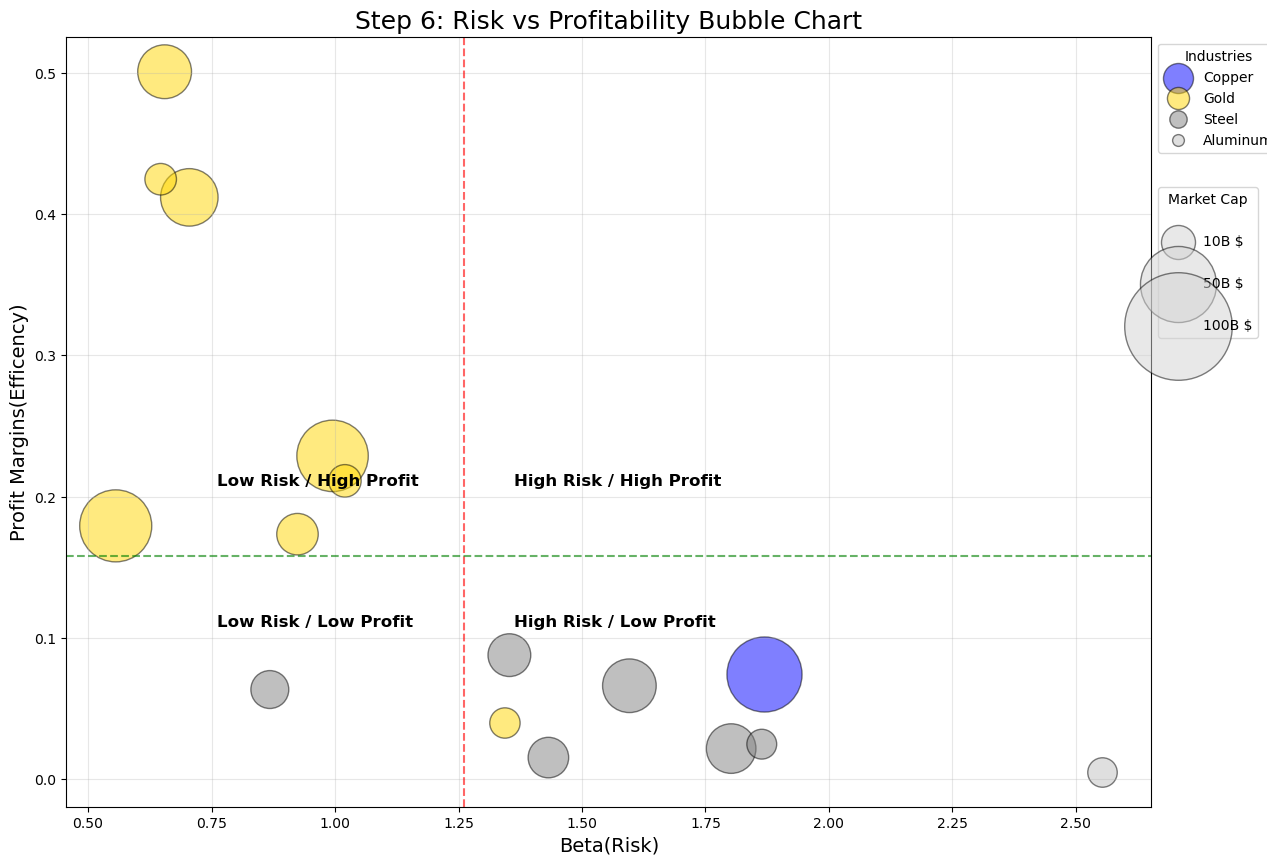

In [18]:
#STEP 6

# Encoding Choices:
# 1. X-axis: Beta -> Measures systematic risk/volatility relative to the market.
# 2. Y-axis: Profit Margins -> Measures operational efficiency and profitability.
# 3. Size: Market Cap (Billions) -> Represents the total financial size/weight of the company.
# 4. Color: Industry -> Helps identify sectoral clusters and trends.

plt.figure(figsize=(14,10))

colors = {'Copper': 'blue', 'Gold': 'gold', 'Steel': 'grey', 'Aluminum': 'silver'} # I'm creating a dictionary in which the key is the industry and the value is the corresponding color

for ind in selected_industries:
    subset = df_industries[df_industries['industry'] == ind]
    plt.scatter(subset['beta'], subset['profit_margins'], s= subset['market_cap_b']* 50, alpha=0.5, label=ind, color = colors[ind], edgecolors='black') # I'm plotting the companies as bubbles, The x-axis represent the Beta and y-axis represent the Profit Margin. The bubble size represent the market capitalization

mean_beta= df_industries['beta'].mean() # i'm computing the mean of the beta
mean_margin = df_industries['profit_margins'].mean() # I'm computing the mean of the profit margin

plt.axvline(mean_beta, color = 'red', linestyle = '--', alpha = 0.6) # i'm adding a vertical line in correspondance of the mean beta
plt.axhline(mean_margin, color = 'green', linestyle = '--', alpha = 0.6) # ''m adding an horizontal line in correspondance of the mean profit margin

plt.text(mean_beta + 0.1, mean_margin + 0.05, 'High Risk / High Profit', fontsize = 12, fontweight = 'bold') 
plt.text(mean_beta - 0.5, mean_margin + 0.05, 'Low Risk / High Profit ', fontsize = 12 ,fontweight = 'bold' )
plt.text(mean_beta - 0.5, mean_margin - 0.05, 'Low Risk / Low Profit', fontsize = 12, fontweight = 'bold')
plt.text(mean_beta + 0.1, mean_margin - 0.05, 'High Risk / Low Profit', fontsize = 12, fontweight = 'bold')

## Labels each quadrant based on the combination of risk (Beta) and profitability.

plt.title('Step 6: Risk vs Profitability Bubble Chart', fontsize = 18)
plt.xlabel('Beta(Risk)', fontsize = 14)
plt.ylabel('Profit Margins(Efficency)', fontsize = 14)

leg1 = plt.legend(title="Industries", loc='upper left', bbox_to_anchor=(1, 1),  # I'm creating the first legend for the industry colors, placing it outside the chart
                  markerscale=0.4, fontsize=10)

# I'm creating bubbles of different size in order to represent different Market Cap sizes.
s1 = plt.scatter([], [], s=10*60, color='lightgray', edgecolors='black', alpha=0.5)
s2 = plt.scatter([], [], s=50*60, color='lightgray', edgecolors='black', alpha=0.5)
s3 = plt.scatter([], [], s=100*60, color='lightgray', edgecolors='black', alpha=0.5)


plt.legend([s1, s2, s3], ['10B $', '50B $', '100B $'], title="Market Cap", # I'm adding another legend in order to explain the bubble sizes
           loc='lower left', bbox_to_anchor=(1, 0.6), fontsize=10, labelspacing=2)


plt.gca().add_artist(leg1) # I'm manually re-adding the first legend otherwise Matplotlib would overwrite it.
plt.grid(True, alpha = 0.3)

plt.show()

the number of selected companies is:8


[**********************75%***********            ]  6 of 8 completed$X: possibly delisted; no price data found  (period=3mo) (Yahoo error = "No data found, symbol may be delisted")
[*********************100%***********************]  7 of 8 completed

1 Failed download:
['X']: possibly delisted; no price data found  (period=3mo) (Yahoo error = "No data found, symbol may be delisted")


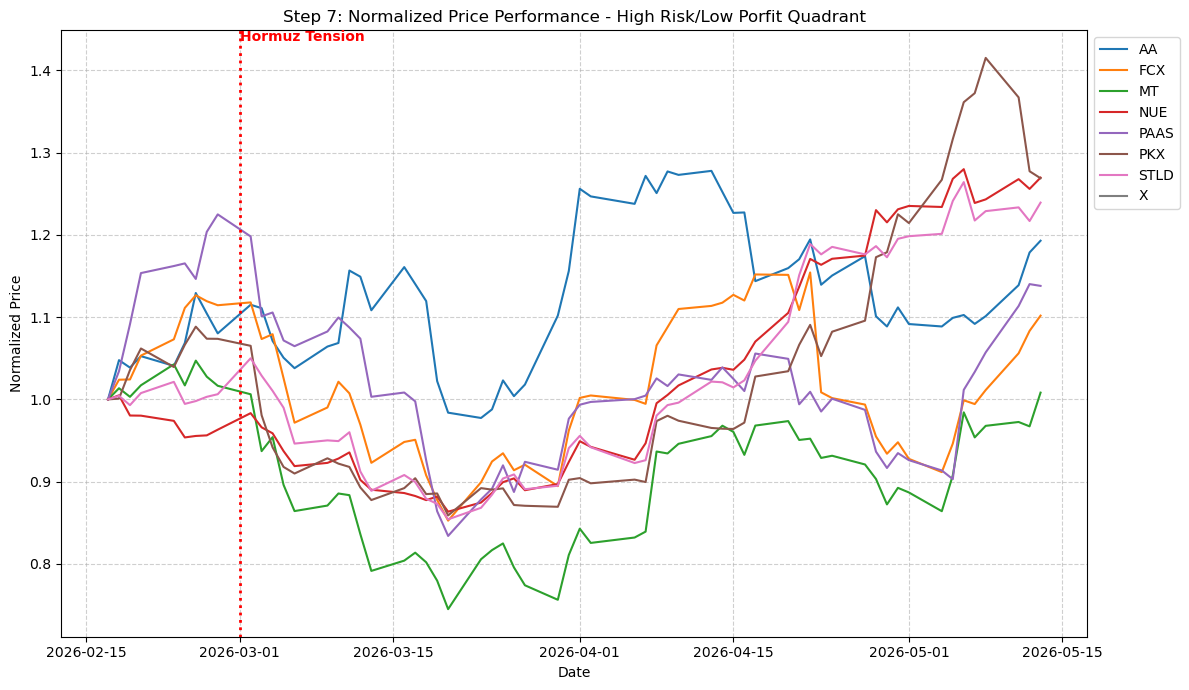

In [19]:
# STEP 7
 

choosen_quadrant= df_industries[(df_industries['beta'] > mean_beta) & (df_industries['profit_margins'] < mean_margin)]# Since I'm choosing the high risk / low profit quadrant, I'm considering the companies which exibith a beta greater than the corresponding mean and a profit margin lower than the corresponding mean.

print(f'the number of selected companies is:{len(choosen_quadrant)}') # since the number of companies is equal to 8, I just consider all of them

tickers_list = choosen_quadrant['symbol'].tolist() # I'm creating a list made of the symbol of each selected company

data = yf.download(tickers_list, period= '3mo')['Close'] # I'm downloading the data from yahoo finance regarding the closing price of the last 3 month

normalized_data = data / data.iloc[0] # I'm normalizing the data to 1

plt.figure(figsize=(12,7))
for company in normalized_data.columns:
    plt.plot(normalized_data.index, normalized_data[company], label = company) # I'm plotting the data about the closing price of the last 3 month for each company


hormuz_date = '2026-03-01'

plt.axvline(pd.to_datetime(hormuz_date), color= 'red', linestyle = ':', linewidth = 2)
plt.text(pd.to_datetime(hormuz_date), plt.ylim()[1], 'Hormuz Tension', verticalalignment= 'top', fontsize = 10, color= 'red', fontweight = 'bold')


plt.title('Step 7: Normalized Price Performance - High Risk/Low Porfit Quadrant')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend(loc = 'upper left', bbox_to_anchor =(1,1))
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.tight_layout()
plt.show()






Considering the companies which belong to the High Risk/ Low Profit quadrant, I can observe several patterns following the Hormuz tension event:

Firstly, after the red line, almost all the companies experienced a sharp drop, thus confirming that high-beta companies with low margins are extremely sensitive to geopolitical shocks that threaten global supply chains.

The plot also shows that this decline was gradual and volatile, lasting for about 3 weeks.

However, from early April 2026 there is a significant sign of recovery, thus suggesting that the scarcity of raw materials drove commodity prices high enough to offset the increased logistic cost.




the number of companies is 7


[*********************100%***********************]  7 of 7 completed


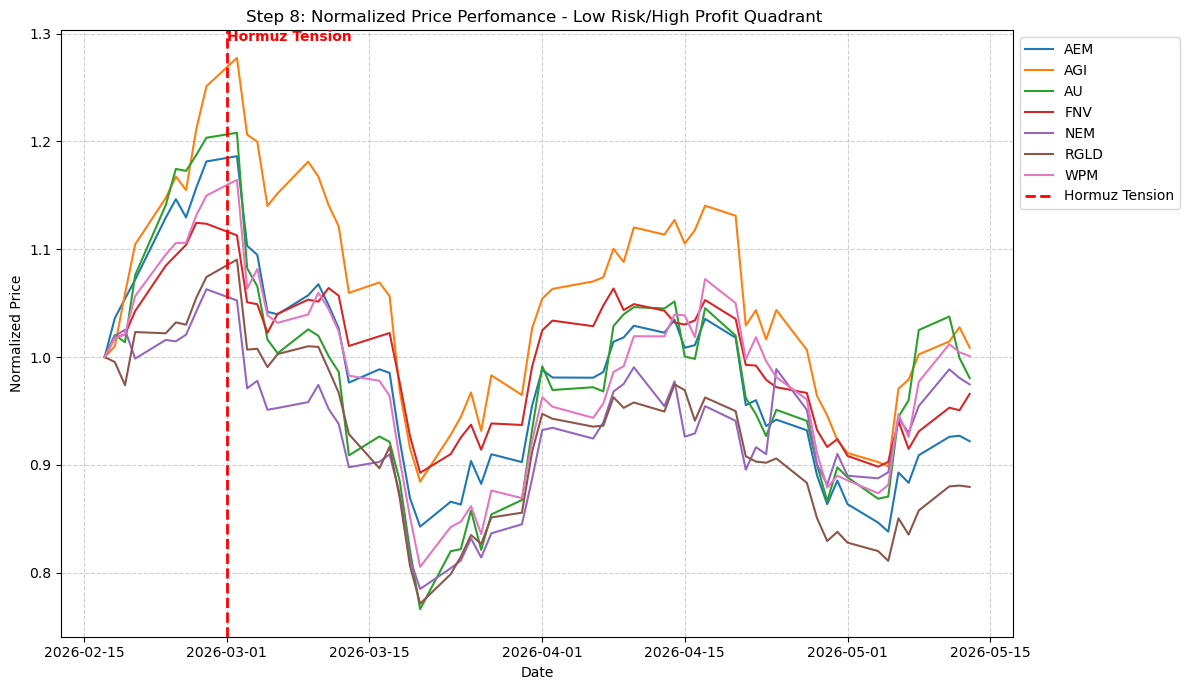

In [20]:
#STEP 8

comperison_quadrant = df_industries[(df_industries['beta'] < mean_beta) & (df_industries['profit_margins'] > mean_margin)] # I'm selecting the opposite quadrant 

if len(comperison_quadrant) > 10:
    comperison_quadrant = comperison_quadrant.sort_values(by = 'market_cap_b', ascending= False).head(10) # Here I'm saying that if there are more than 10 companies that belong to that quadrant, I sort all of them and then I take the first 10 with the highest market capitalization

print(f'the number of companies is {len(comperison_quadrant)}')

comparison_ticker = comperison_quadrant['symbol'].tolist()

comparison_data = yf.download(comparison_ticker, period='3mo')['Close']

comparison_normalized = comparison_data/ comparison_data.iloc[0]

plt.figure(figsize=(12,7))
for company in comparison_normalized.columns:
    plt.plot(comparison_normalized.index, comparison_normalized[company], label = company)

plt.axvline(pd.to_datetime(hormuz_date), color = 'red', linestyle = '--', linewidth = 2, label = 'Hormuz Tension')
plt.text(pd.to_datetime(hormuz_date), plt.ylim()[1], 'Hormuz Tension', verticalalignment= 'top', fontsize = 10, color= 'red', fontweight = 'bold')

plt.title('Step 8: Normalized Price Perfomance - Low Risk/High Profit Quadrant ')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend(loc = 'upper left', bbox_to_anchor=(1,1))
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.tight_layout()
plt.show()

COMPARISON BETWEEN THE 2 QUADRANT:

While both groups have been impacted by the geopolitical tension, the group belonging to the Low Risk / High Profit quadrant seems to be more resilient and its collapse is more cushioned. By contrast, the companies belonging to the High Risk / Low Profit quadrant experienced a synchronized and aggressive collapse.

Regarding volatility, in Step 8 the price action appears less nervous. This is due to the fact that I am considering companies with a lower Beta. Conversely, in Step 7, the stock prices overreacted to the Hormuz Tension, showing higher sensitivity to market shocks.

In addition, the high Profit Margins in the Step 8 group allow companies to remain fundamentally sound even in crisis situations where energy and logistic costs increase. This operational efficiency acts as a "buffer" that prevents extreme price drops.

Finally, the companies in the Low Risk / High Profit quadrant seem to have a more stable and synchronized recovery compared to the more volatile and fragmented rebound seen in the High Risk / Low Profit group.



FINAL SUMMARY

Sector Structure: Size, Profitability, and Risk

The initial analysis of the Basic Materials sector revealed a highly fragmented landscape. The sector is characterized by a significant presence of "Giants" (high Market Cap) in industries like Steel and Copper, which provide the backbone for global infrastructure but often operate with cyclical profitability. In terms of risk, the sector shows a broad range of Beta values, reflecting its sensitivity to macroeconomic cycles. While some industries maintain stable, low-risk profiles, others—specifically those linked to industrial production—exhibit high volatility and market sensitivity.

Industry Selection

I focused my analysis on four key industries: Gold, Copper, Steel, and Aluminum. These were selected to represent a balanced "stress test" of the sector:

Gold was chosen as a classic "Safe Haven" with traditionally higher margins.

Steel and Copper represent the industrial heavyweights with massive scale but tighter margins.

Aluminum was included due to its high-risk profile and extreme energy dependency, making it a primary candidate for observing geopolitical shocks.

Bubble Chart Insights

The Step 6 Bubble Chart was a turning point in the analysis, visually confirming the "Quadrant Logic." It revealed a clear divide:

Gold companies clustered in the Low Risk / High Profit quadrant, confirming their efficiency and defensive nature.

Steel and Aluminum companies were largely positioned in the High Risk or Low Profit zones.
This visualization highlighted that company size (Market Cap) does not always correlate with safety; some of the largest players in Steel were found to be more vulnerable (High Beta) than smaller, high-margin Gold miners.

Geopolitical Performance & The Hormuz Crisis

The 3-month price analysis (Step 7 and 8) provided empirical evidence of how financial metrics predict real-world resilience:

High Risk / Low Profit Group: As expected, these companies reacted violently to the Strait of Hormuz tensions. The "sharp drop" observed in early March confirmed that firms with thin margins and high market sensitivity have no "buffer" to absorb the increased logistics and energy costs caused by such crises.

Low Risk / High Profit Group: This group proved to be significantly more resilient. While they experienced a market-wide dip, their decline was "cushioned." The recovery starting in April was more stable, likely driven by investors seeking "Safe Havens" and the fact that high-margin companies can better withstand temporary spikes in operational costs.

Conclusion

The analysis confirms that Beta and Profit Margins are not just theoretical metrics but effective predictors of geopolitical vulnerability. In the face of supply chain disruptions like those in the Middle East, the "Safe Haven" logic of the Low Risk / High Profit quadrant remains the most valid defensive strategy for investors in the Basic Materials sector.